In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import shapiro
!pip install arch
from arch.unitroot import DFGLS, PhillipsPerron, ZivotAndrews
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 15.4 MB/s eta 0:00:00


In [3]:
ticker = "GC=F" # ouro futuro
data_diaria = yf.download(ticker, start="2000-01-01", end="2024-12-31",
                           interval="1d", progress=False)

serie_diaria = data_diaria["Close"]
if isinstance(serie_diaria, pd.DataFrame):
    serie_diaria = serie_diaria.iloc[:, 0]  # força Series, pega a única coluna
serie_diaria = serie_diaria.dropna()
serie_diaria.name = "ouro"

# Resample para mensal, usa o último preço de fechamento disponível em cada mês
serie = serie_diaria.resample("MS").last()
serie.name = "ouro"

print("Total de observações (mensal via resample):", len(serie))
print(type(serie))

full_index = pd.date_range(serie.index.min(), serie.index.max(), freq="MS")
faltantes_reais = full_index.difference(serie.dropna().index)
print(f"Meses ainda ausentes: {len(faltantes_reais)}")
if len(faltantes_reais) > 0:
    print([d.strftime("%Y-%m") for d in faltantes_reais])
    serie = serie.reindex(full_index).interpolate(method="linear")

serie = serie.asfreq("MS")
serie.name = "ouro"

print(serie.head())
print(serie.tail())

# Salvar dados brutos
serie.to_csv("dados_ouro.csv")

# Divisão treino/teste
ultimo_mes_disponivel = serie.index.max()
print(f"\nÚltimo mês disponível na série: {ultimo_mes_disponivel.strftime('%Y-%m')}")

train = serie[:"2023-12-31"]
test = serie["2024-01-01":ultimo_mes_disponivel]

print("\nTreino:", train.index.min(), "a", train.index.max(), "-", len(train), "obs")
print("Teste:", test.index.min(), "a", test.index.max(), "-", len(test), "obs")

Total de observações (mensal via resample): 293
<class 'pandas.core.series.Series'>
Meses ainda ausentes: 0
Date
2000-08-01    278.299988
2000-09-01    273.600006
2000-10-01    264.899994
2000-11-01    270.100006
2000-12-01    272.000000
Freq: MS, Name: ouro, dtype: float64
Date
2024-08-01    2493.800049
2024-09-01    2636.100098
2024-10-01    2738.300049
2024-11-01    2657.000000
2024-12-01    2606.100098
Freq: MS, Name: ouro, dtype: float64

Último mês disponível na série: 2024-12

Treino: 2000-08-01 00:00:00 a 2023-12-01 00:00:00 - 281 obs
Teste: 2024-01-01 00:00:00 a 2024-12-01 00:00:00 - 12 obs


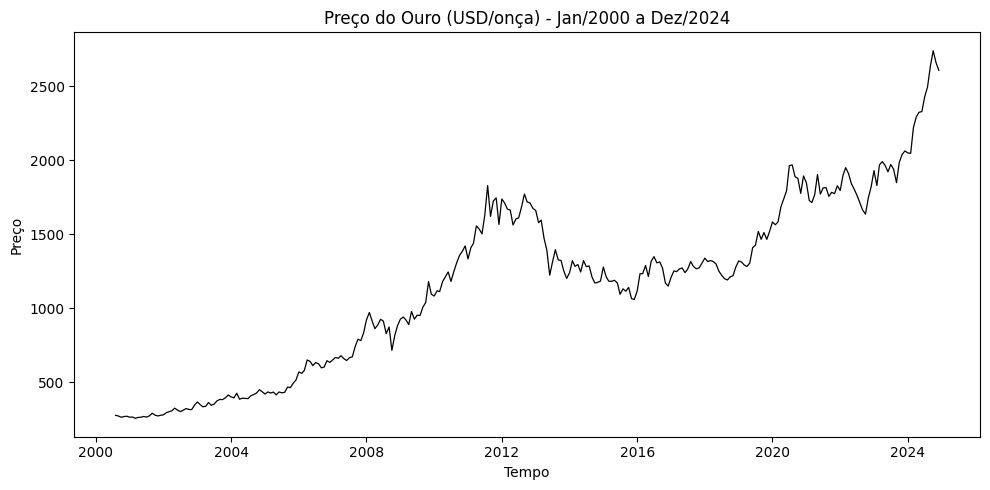

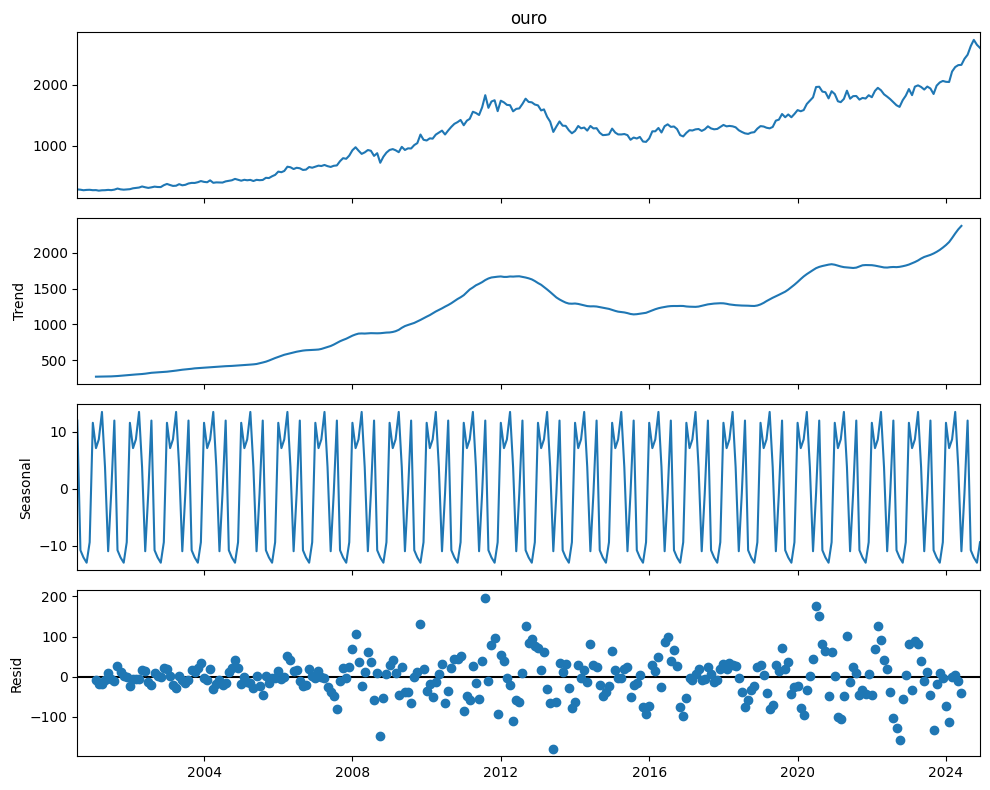


Estatísticas descritivas:
                                  0
Média                  1158.629011
Mediana                1233.900024
Desvio Padrão           583.084492
Mínimo                  257.899994
Máximo                 2738.300049
Coef. de Variação (%)    50.325383


In [4]:
#INSPEÇÃO VISUAL DA SÉRIE
fig, ax = plt.subplots()
ax.plot(serie.index, serie.values, color="black", linewidth=0.9)
ax.set_title("Preço do Ouro (USD/onça) - Jan/2000 a Dez/2024")
ax.set_xlabel("Tempo")
ax.set_ylabel("Preço")
plt.tight_layout()
plt.savefig("fig1_serie_nivel.png", dpi=150)
plt.show()
plt.close()


# Decomposição (aditiva, period=12 para dados mensais)
decomp = seasonal_decompose(serie, model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.savefig("fig2_decomposicao.png", dpi=150)
plt.show()
plt.close()


# Estatísticas descritivas
desc = pd.DataFrame({
    "Média": [serie.mean()],
    "Mediana": [serie.median()],
    "Desvio Padrão": [serie.std()],
    "Mínimo": [serie.min()],
    "Máximo": [serie.max()],
    "Coef. de Variação (%)": [100 * serie.std() / serie.mean()],
})
print("\nEstatísticas descritivas:\n", desc.T)
desc.T.to_csv("tabela_estatisticas_descritivas.csv")

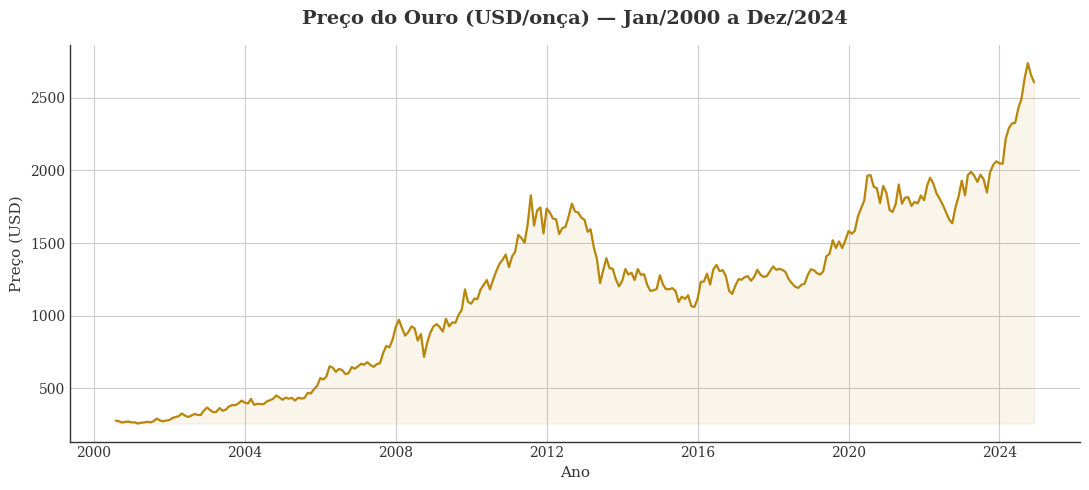

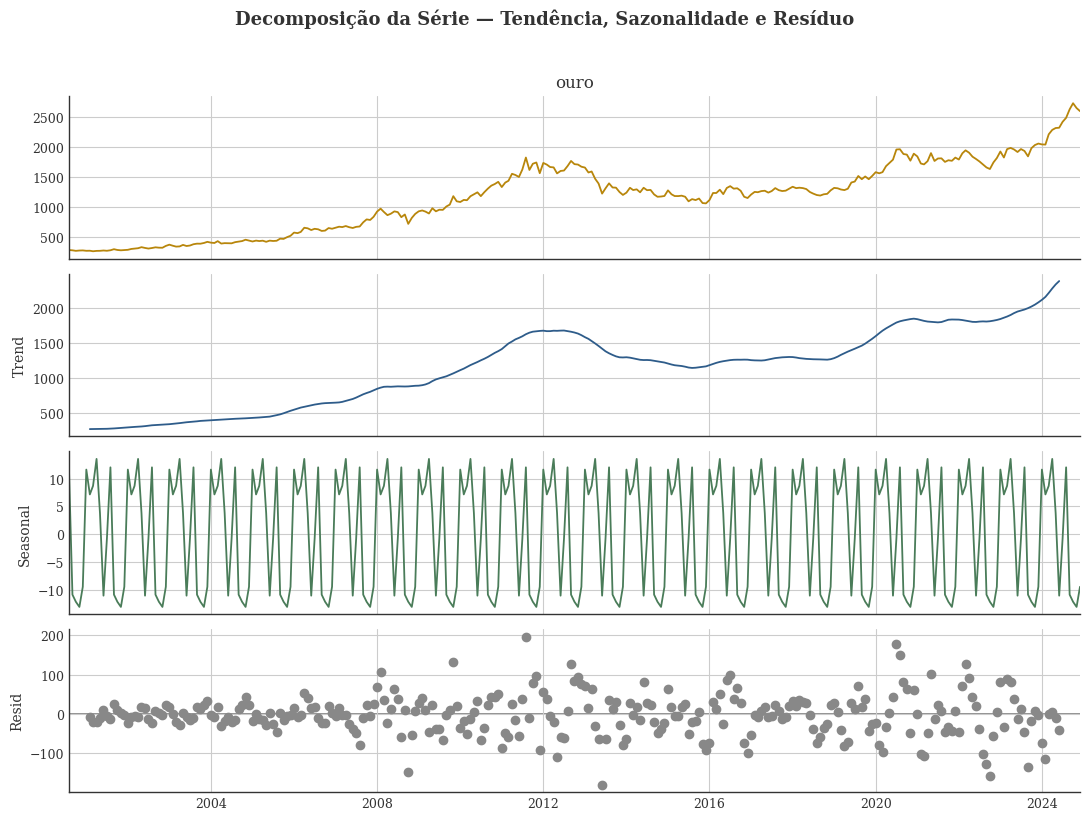


Estatísticas descritivas:
                                  0
Média                  1158.629011
Mediana                1233.900024
Desvio Padrão           583.084492
Mínimo                  257.899994
Máximo                 2738.300049
Coef. de Variação (%)    50.325383


In [5]:

# INSPEÇÃO VISUAL DA SÉRIE

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
})

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie.index, serie.values, color="#B8860B", linewidth=1.6)  # tom dourado, temático
ax.fill_between(serie.index, serie.values, serie.values.min(), color="#B8860B", alpha=0.08)

ax.set_title("Preço do Ouro (USD/onça) — Jan/2000 a Dez/2024",
              fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Ano", fontsize=11)
ax.set_ylabel("Preço (USD)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig("fig1_serie_nivel.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# Decomposição (aditiva, period=12 para dados mensais)
decomp = seasonal_decompose(serie, model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(11, 8)

cores = ["#B8860B", "#2E5C8A", "#4A7C59", "#888888"]
for axis, cor in zip(fig.axes, cores):
    for line in axis.get_lines():
        line.set_color(cor)
        line.set_linewidth(1.3)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.tick_params(labelsize=9)

fig.suptitle("Decomposição da Série — Tendência, Sazonalidade e Resíduo",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig2_decomposicao.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# Estatísticas descritivas
desc = pd.DataFrame({
    "Média": [serie.mean()],
    "Mediana": [serie.median()],
    "Desvio Padrão": [serie.std()],
    "Mínimo": [serie.min()],
    "Máximo": [serie.max()],
    "Coef. de Variação (%)": [100 * serie.std() / serie.mean()],
})
print("\nEstatísticas descritivas:\n", desc.T)
desc.T.to_csv("tabela_estatisticas_descritivas.csv")

In [6]:
# TESTES DE RAIZ UNITÁRIA - SÉRIE EM NÍVEL (sobre o treino)


def adf_test(series, regression="ct"):
    """ADF com constante e tendência (ct)"""
    result = adfuller(series, regression=regression, autolag="AIC")
    return {"Estatística": result[0], "Valor Crítico (5%)": result[4]["5%"], "p-valor": result[1]}

def kpss_test(series, regression="ct"):
    result = kpss(series, regression=regression, nlags="auto")
    return {"Estatística": result[0], "Valor Crítico (5%)": result[3]["5%"], "p-valor": result[1]}

def run_root_tests(series, label):
    print(f"\n=== Testes de raiz unitária: {label} ===")

    adf_res = adf_test(series)
    kpss_res = kpss_test(series)
    dfgls_res = DFGLS(series, trend="ct")
    pp_res = PhillipsPerron(series, trend="ct")
    za_res = ZivotAndrews(series, trend="ct")

    tabela = pd.DataFrame({
        "Teste": ["ADF", "PP", "KPSS", "ERS - DF-GLS", "ZA"],
        "Estatística de Teste": [
            adf_res["Estatística"],
            pp_res.stat,
            kpss_res["Estatística"],
            dfgls_res.stat,
            za_res.stat,
        ],
        "Valor Crítico (5%)": [
            adf_res["Valor Crítico (5%)"],
            pp_res.critical_values["5%"],
            kpss_res["Valor Crítico (5%)"],
            dfgls_res.critical_values["5%"],
            za_res.critical_values["5%"],
        ],
        "p-valor": [
            adf_res["p-valor"],
            pp_res.pvalue,
            kpss_res["p-valor"],
            np.nan,  # DF-GLS não retorna p-valor diretamente
            za_res.pvalue,
        ],
    })
    print(tabela)
    return tabela

tab1 = run_root_tests(train, "Série em nível")
tab1.to_csv("tabela1_raiz_unitaria_nivel.csv", index=False)

# Diferenciação
train_diff = train.diff().dropna()

fig, ax = plt.subplots()
ax.plot(train_diff.index, train_diff.values, color="black", linewidth=0.9)
ax.set_title("Série Diferenciada (d=1)")
ax.set_xlabel("Tempo")
ax.set_ylabel("Δ Preço")
plt.tight_layout()
plt.savefig("fig3_serie_diferenciada.png", dpi=150)
plt.close()

tab2 = run_root_tests(train_diff, "Série em primeira diferença")
tab2.to_csv("tabela2_raiz_unitaria_diferenca.csv", index=False)


=== Testes de raiz unitária: Série em nível ===
          Teste  Estatística de Teste  Valor Crítico (5%)   p-valor
0           ADF             -1.858272           -3.426344  0.676006
1            PP             -2.124680           -3.426287  0.532251
2          KPSS              0.265876            0.146000  0.010000
3  ERS - DF-GLS             -1.875527           -2.916297       NaN
4            ZA             -4.137141           -5.073320  0.413531

=== Testes de raiz unitária: Série em primeira diferença ===
          Teste  Estatística de Teste  Valor Crítico (5%)   p-valor
0           ADF            -18.916514           -3.426344  0.000000
1            PP            -18.924426           -3.426344  0.000000
2          KPSS              0.076645            0.146000  0.100000
3  ERS - DF-GLS            -18.850335           -2.916297       NaN
4            ZA            -19.700607           -5.073320  0.000586


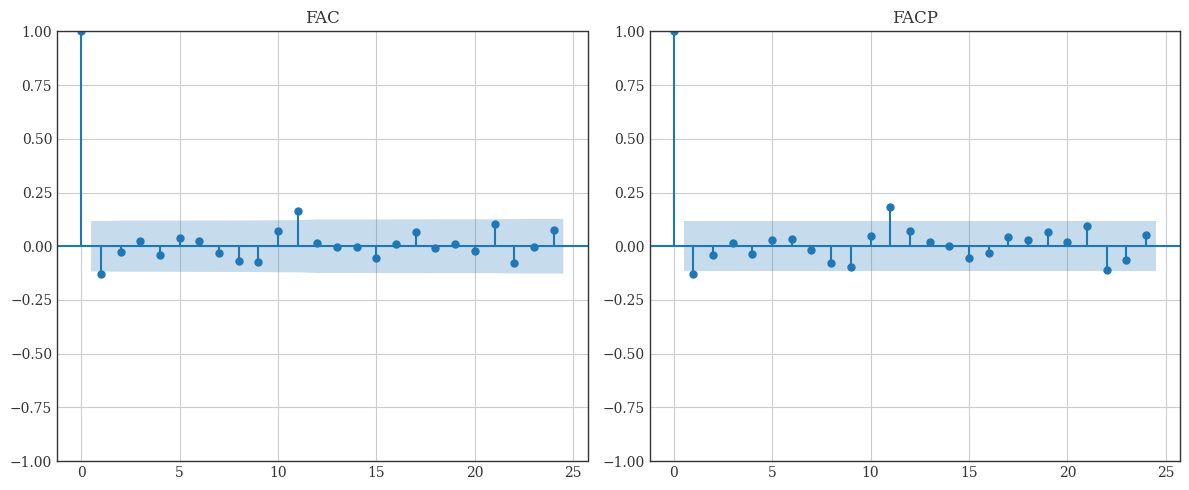

In [7]:
# IDENTIFICAÇÃO - FAC E FACP

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(train_diff, lags=24, ax=axes[0])
axes[0].set_title("FAC")
plot_pacf(train_diff, lags=24, ax=axes[1])
axes[1].set_title("FACP")
plt.tight_layout()
plt.savefig("fig4_fac_facp.png", dpi=150)
plt.show()
plt.close()

In [8]:
# ESTIMAÇÃO DE MODELOS ARIMA CANDIDATOS

# Ajuste as ordens (p,d,q) com base na inspeção real da FAC/FACP do seu gráfico

candidatos = [(1, 1, 0), (0, 1, 1), (1, 1, 1)]
modelos = {}
criterios = []

for ordem in candidatos:
    modelo = ARIMA(train, order=ordem).fit()
    modelos[ordem] = modelo
    criterios.append({
        "Modelo": f"ARIMA{ordem}",
        "AIC": modelo.aic,
        "BIC": modelo.bic,
    })

tab_criterios = pd.DataFrame(criterios)
print("\nCritérios de informação:\n", tab_criterios)
tab_criterios.to_csv("tabela3_criterios_informacao.csv", index=False)

# Escolher os 2 melhores modelos (menor AIC/BIC) para diagnóstico e previsão
melhores = tab_criterios.nsmallest(2, "BIC")["Modelo"].tolist()
print("\nModelos selecionados para diagnóstico:", melhores)


Critérios de informação:
            Modelo          AIC          BIC
0  ARIMA(1, 1, 0)  3063.744868  3071.014447
1  ARIMA(0, 1, 1)  3063.615208  3070.884787
2  ARIMA(1, 1, 1)  3065.608716  3076.513085

Modelos selecionados para diagnóstico: ['ARIMA(0, 1, 1)', 'ARIMA(1, 1, 0)']


In [9]:

# DIAGNÓSTICO DOS RESÍDUOS

diagnostico_ljungbox = []
diagnostico_normalidade = []

for ordem in candidatos:
    modelo = modelos[ordem]
    nome = f"ARIMA{ordem}"
    residuos = modelo.resid

    # Ljung-Box (lag = 24, comum para dados mensais)
    lb = acorr_ljungbox(residuos, lags=[24], return_df=True)
    diagnostico_ljungbox.append({
        "Modelo": nome,
        "Q*": lb["lb_stat"].values[0],
        "gl": 24,
        "p-valor": lb["lb_pvalue"].values[0],
        "Conclusão": "Não rejeita H0" if lb["lb_pvalue"].values[0] > 0.05 else "Rejeita H0",
    })

    # Jarque-Bera
    jb_stat, jb_p, _, _ = jarque_bera(residuos)
    # Shapiro-Wilk
    sw_stat, sw_p = shapiro(residuos)
    # ARCH-LM
    arch_stat, arch_p, _, _ = het_arch(residuos)

    diagnostico_normalidade.append({"Teste": "Jarque-Bera", "Modelo": nome, "Estatística": jb_stat, "p-valor": jb_p})
    diagnostico_normalidade.append({"Teste": "Shapiro-Wilk", "Modelo": nome, "Estatística": sw_stat, "p-valor": sw_p})
    diagnostico_normalidade.append({"Teste": "ARCH-LM", "Modelo": nome, "Estatística": arch_stat, "p-valor": arch_p})

tab_ljungbox = pd.DataFrame(diagnostico_ljungbox)
tab_normalidade = pd.DataFrame(diagnostico_normalidade)
print("\nLjung-Box:\n", tab_ljungbox)
print("\nNormalidade/Heterocedasticidade:\n", tab_normalidade)
tab_ljungbox.to_csv("tabela4_ljungbox.csv", index=False)
tab_normalidade.to_csv("tabela5_normalidade_arch.csv", index=False)


Ljung-Box:
            Modelo         Q*  gl   p-valor       Conclusão
0  ARIMA(1, 1, 0)  22.253139  24  0.564161  Não rejeita H0
1  ARIMA(0, 1, 1)  21.675448  24  0.598631  Não rejeita H0
2  ARIMA(1, 1, 1)  21.517640  24  0.608033  Não rejeita H0

Normalidade/Heterocedasticidade:
           Teste          Modelo  Estatística       p-valor
0   Jarque-Bera  ARIMA(1, 1, 0)    72.844273  1.520783e-16
1  Shapiro-Wilk  ARIMA(1, 1, 0)     0.965476  2.899511e-06
2       ARCH-LM  ARIMA(1, 1, 0)    49.657648  3.085198e-07
3   Jarque-Bera  ARIMA(0, 1, 1)    73.262614  1.233745e-16
4  Shapiro-Wilk  ARIMA(0, 1, 1)     0.965056  2.534417e-06
5       ARCH-LM  ARIMA(0, 1, 1)    48.658315  4.704535e-07
6   Jarque-Bera  ARIMA(1, 1, 1)    73.427390  1.136174e-16
7  Shapiro-Wilk  ARIMA(1, 1, 1)     0.964909  2.418792e-06
8       ARCH-LM  ARIMA(1, 1, 1)    48.507649  5.012854e-07



Medidas de erro:
            Modelo          ME        RMSE         MAE        MPE       MAPE  \
0  ARIMA(1, 1, 0)  341.066870  407.165500  345.306562  13.446907  13.654035   
1  ARIMA(0, 1, 1)  342.368493  408.274863  346.209570  13.501454  13.689108   
2  ARIMA(1, 1, 1)  342.801895  408.648940  346.518900  13.519582  13.701174   

       MASE  
0  8.318421  
1  8.340175  
2  8.347627  

Observado vs Previsto:
               Observado  ARIMA(1, 1, 0)  ARIMA(0, 1, 1)  ARIMA(1, 1, 1)
Date                                                                   
2024-01-01  2048.399902     2059.608698     2058.573157     2058.269651
2024-02-01  2045.699951     2059.929309     2058.573157     2058.132232
2024-03-01  2217.399902     2059.892482     2058.573157     2058.127660
2024-04-01  2291.399902     2059.896712     2058.573157     2058.127508
2024-05-01  2322.899902     2059.896226     2058.573157     2058.127502
2024-06-01  2327.699951     2059.896282     2058.573157     2058.127502
2024-07

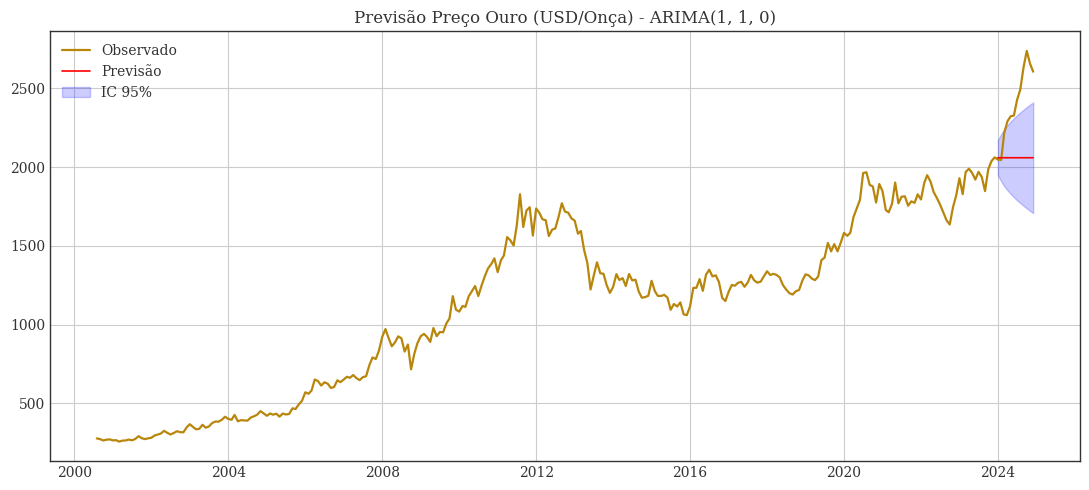

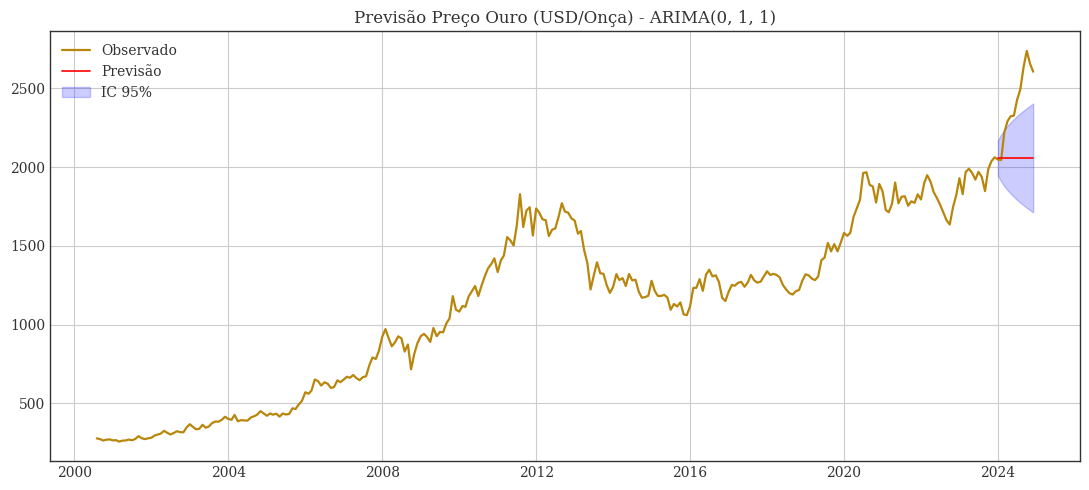

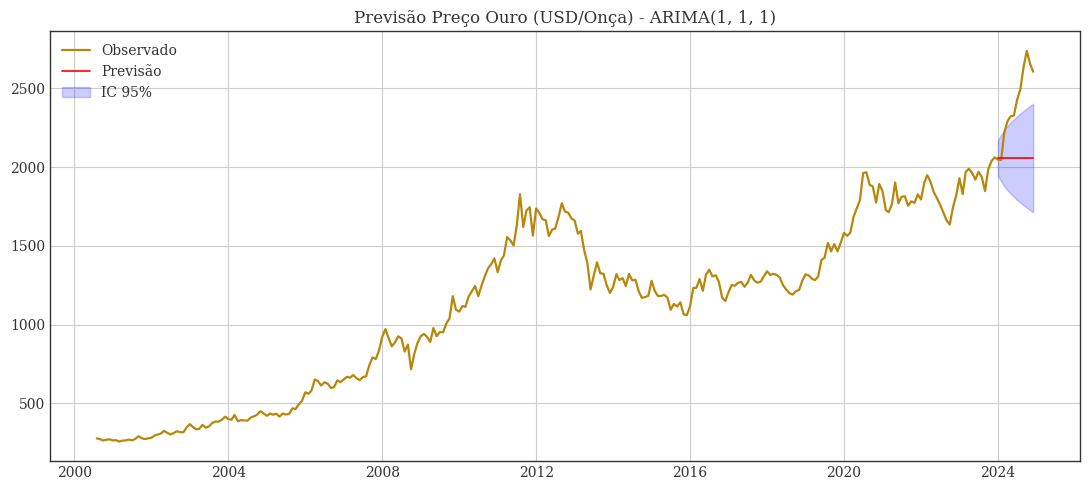


Melhor modelo (menor RMSE): ARIMA(1, 1, 0)

Script finalizado. Todos os arquivos (.csv e .png) foram salvos no diretório atual.


In [10]:

# PREVISÃO E MEDIDAS DE ERRO


n_test = len(test)
previsoes = {}
erros = []

for ordem in candidatos:
    modelo = modelos[ordem]
    nome = f"ARIMA{ordem}"
    forecast = modelo.get_forecast(steps=n_test)
    pred = forecast.predicted_mean
    pred.index = test.index
    previsoes[nome] = pred

    erro = test.values - pred.values
    me = np.mean(erro)
    rmse = np.sqrt(np.mean(erro**2))
    mae = np.mean(np.abs(erro))
    mpe = np.mean(erro / test.values) * 100
    mape = np.mean(np.abs(erro / test.values)) * 100
    # MASE: usa erro absoluto médio do passeio aleatório (naive) no treino como benchmark
    naive_mae = np.mean(np.abs(train.diff().dropna()))
    mase = mae / naive_mae

    erros.append({"Modelo": nome, "ME": me, "RMSE": rmse, "MAE": mae,
                   "MPE": mpe, "MAPE": mape, "MASE": mase})

tab_erros = pd.DataFrame(erros)
print("\nMedidas de erro:\n", tab_erros)
tab_erros.to_csv("tabela7_medidas_erro.csv", index=False)

# Tabela de observados vs previstos
tab_previsto = pd.DataFrame({"Observado": test.values}, index=test.index)
for nome, pred in previsoes.items():
    tab_previsto[nome] = pred.values
print("\nObservado vs Previsto:\n", tab_previsto)
tab_previsto.to_csv("tabela6_observado_previsto.csv")

# Gráficos de previsão
for ordem in candidatos:
    nome = f"ARIMA{ordem}"
    modelo = modelos[ordem]
    forecast = modelo.get_forecast(steps=n_test)
    pred_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    #fig, ax = plt.subplots()
    #ax.plot(serie.index, serie.values, color="black", linewidth=0.8, #label="Observado")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(serie.index, serie.values, color="#B8860B", linewidth=1.6, label= "Observado" )  # tom dourado, temático

    pred_index = test.index
    ax.plot(pred_index, pred_mean.values, color="red", linewidth=1.2, label="Previsão")
    ax.fill_between(pred_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                     color="blue", alpha=0.2, label="IC 95%")
    ax.set_title(f"Previsão Preço Ouro (USD/Onça) - {nome}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"fig_previsao_{ordem}.png", dpi=150)
    plt.show()
    plt.close()

print("\nMelhor modelo (menor RMSE):", tab_erros.loc[tab_erros["RMSE"].idxmin(), "Modelo"])
print("\nScript finalizado. Todos os arquivos (.csv e .png) foram salvos no diretório atual.")